## Import the necessary functions 

In [7]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

# To create the ocean profile 
from scipy.spatial import cKDTree

## Set variables 

In [8]:
# Set the filepaths and any variables 

# NEMO simulation temperature and salinity profiles 
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'

# Set the filepaths 
# The target grid mask 
filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
# The target grid geometry
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
# The eORCA1 bedmachine mask
filepath_eORCA1_bmach_masks = '/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc'

# Neural network filepaths 
path_model = '/bettik/ockendeh/NEMO_simulations/models/'
path_norm_metrics = '/bettik/ockendeh/NEMO_simulations/models/'

# And the location of the output files 
filepath_nn_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/'
simulation = 'DUM001' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 

# Any parameters which need to be set 
# Which neural network have you chosen?
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
exp_name = 'slope_front'
join_ice_shelves = True

## Apply neural network

In [9]:
import time

In [12]:
%%time
apply_nn_to_NEMO(filepath_nemo_output, 
                     filepath_mask, 
                     filepath_geomvars, 
                     filepath_eORCA1_bmach_masks, 
                     path_model, 
                     path_norm_metrics, 
                     filepath_nn_output, 
                     simulation, 
                     year_of_interest, 
                     this_collection, 
                     exp_name, 
                     join_ice_shelves, 
                     verbose = 0)

You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc
You have loaded: /bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc
Ice shelves joined, as requested
You have loaded coordinates: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
You have loaded T and S: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
Loaded data. Time: 0.2 s
There are 5 basins with no ocean profiles : [20, 96, 109, 112, 154]
There should be 5 basins (2 with no cavities plus 3 where we merged)
Created T/S profiles. Time: 9.1 s
Prepared data to apply NN. Time: 12.5 s
Applying neural networks
Applied NN. Time: 55.4 sTime: 42.8 s
Putting melt back onto the ocean grid
Propagated melt to ocean cells. Time: 56.7 s
You have saved the nn output to: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_output_melt_DUM001_9999.nc

## Look at the resulting melt distribution map for NEMO

/tmp/ipykernel_2233239/1204333570.py:6: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(-melt_all), cmap = 'Reds')
/tmp/ipykernel_2233239/1204333570.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = -0.08)
/tmp/ipykernel_2233239/1204333570.py:11: RuntimeWarning: invalid value encountered in log10
  im = plt.pcolor(np.log10(melt_all), cmap = 'Blues')
/tmp/ipykernel_2233239/1204333570.py:13: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im, ax= ax, pad = 0)


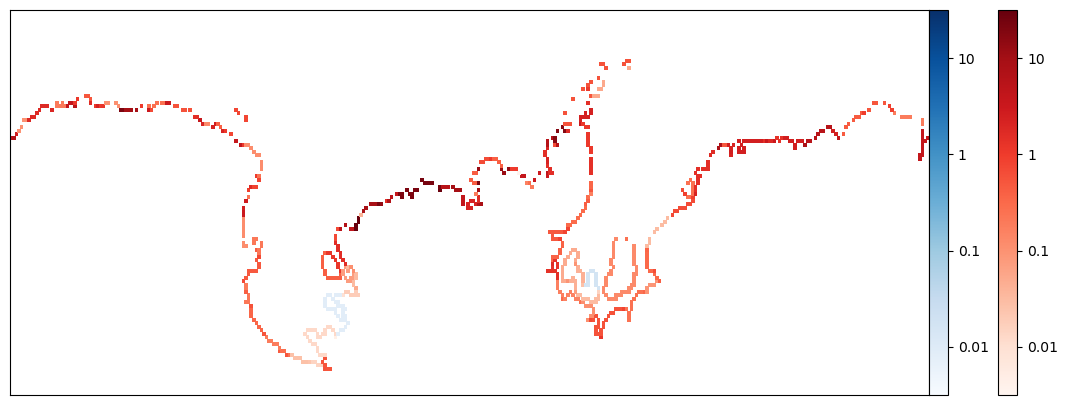

In [5]:
melt = xr.open_dataset(filepath_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc')
melt_all = melt.melt.values
melt.close()
melt_all[melt_all == 0] = np.nan

fig, ax = plt.subplots(1,1, figsize = (15,5))
im = plt.pcolor(np.log10(-melt_all), cmap = 'Reds')
im.set_clim(-2.5,1.5)
cbar = plt.colorbar(im, ax= ax, pad = -0.08)
cbar.set_ticks((-2,-1,0,1))
cbar.set_ticklabels(((10**-2), (10**-1), (10**0), (10**1)))
im = plt.pcolor(np.log10(melt_all), cmap = 'Blues')
im.set_clim(-2.5,1.5)
cbar = plt.colorbar(im, ax= ax, pad = 0)
cbar.set_ticks((-2,-1,0,1))
cbar.set_ticklabels(((10**-2), (10**-1), (10**0), (10**1)))

ax.set_xticks([]);
ax.set_yticks([]);

#im.set_clim(-0.1,0)
fig.savefig('Output melt.jpg', dpi = 200, bbox_inches = 'tight')

In [6]:
purple

NameError: name 'purple' is not defined

# A more in depth look at what is happening in the apply_nn_to_NEMO function

### Load in the NEMO data, masks associated, and the target grid for the NN

In [ ]:
# Load in the TS grid 
gridT2 = load_TSmelt_normal(filepath_nemo_output)
# Load in the mask for the ocean region 
bmach_masks = xr.open_dataset(filepath_eORCA1_bmach_masks)
mask_nocavs = bmach_masks.mask_nocavs.values
bmach_masks.close()

# Load in the mask and geometry 
masks, basins_merged, geoms = load_geom_files(filepath_geomvars, 
                                              filepath_mask, 
                                              join_ice_shelves = join_ice_shelves)
# Rename the dimensions of basins merged to be x and y 
if 'y_grid_T' in basins_merged.dims:
    basins_merged = basins_merged.rename({"y_grid_T": "y", "x_grid_T": "x"}).astype(int)
# Load in the coordinates for the grid 
coords = load_gridcoords(filepath_nemo_output)
# The basins mask for the NEMO 025 grid  
basins_NEMO = masks.basins_NEMO.values
if join_ice_shelves == True:
    # Dotson and Crosson?
    #basins_NEMO[basins_NEMO == 101] = 129
    # Abbot Ice Shelf
    basins_NEMO[basins_NEMO == 109] = 143
    # George VI
    basins_NEMO[basins_NEMO == 112] = 125
    # Lambert 
    basins_NEMO[basins_NEMO == 20] = 103
basin_nos = np.arange(1,156, dtype = 'float32')

### Create a list of the cells where it is okay to extract ocean profiles 

In [ ]:
# Regions where it is acceptable to extract ocean profiles 
iy, ix = np.where((mask_nocavs == 1))
# coordinates of those cells
lat_ocean = coords.nav_lat.values[iy, ix]
lon_ocean = coords.nav_lon.values[iy, ix]
# Transform to x and y
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x_ocean, y_ocean = transformer.transform(lat_ocean, lon_ocean)
# Stack to prepare for the KDTree
ocean_points = np.column_stack((x_ocean, y_ocean))
# Create KDTree
tree = cKDTree(ocean_points)

In [ ]:
# Making a note to compare the new and old basins for basin 35/36

In [ ]:
plot_basin_nos_map = True
if plot_basin_nos_map == True:
    fig, ax = plt.subplots(1,1, figsize = (10,8))
    for kk in range(len(basin_nos)):
        i = basin_nos[kk]
        mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
        # Extract these points 
        idx = np.where(mask_basin_cavs == 1)
        lat_cavs = masks.lat.values[idx]
        lon_cavs = masks.lon.values[idx]
        # Transform to x and y
        transformer = Transformer.from_crs("epsg:4326","epsg:3031")
        x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
        if len(x_cavs) > 0:
            plt.scatter(np.mean(x_cavs), np.mean(y_cavs), s = 40, c = 'skyblue')
        if np.mod(i,2) == 1: 
            plt.annotate(int(i), xy = (0,0), xytext = (np.mean(x_cavs)*1.04, np.mean(y_cavs)*1.04), fontsize = 8, ha = 'center', va = 'center')
        else:
          plt.annotate(int(i), xy = (0,0), xytext = (np.mean(x_cavs)*0.96, np.mean(y_cavs)*0.96), fontsize = 8, ha = 'center', va = 'center')  
    ax.axis('off');

In [ ]:
# To look at which ocean cells are extracted for each individual basin
plot_figure = True
if plot_figure == True:
    #kk = 100
    #i = basin_nos[kk]
    #i = 104 #(A good example where it comes around the corner)
    i = 125 ## AAAAh George VI
    i = 24
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    ocean_edge_illus = np.zeros_like(mask_nocavs)
    # If you allow all the nearest cells
    # And fill the cells found with the kd-tree
    for k in range(len(idx)):
        ocean_edge_illus[iy[idx[k]], ix[idx[k]]] = 1

    # Only allow cells where the distance is less than 1.5 times the minimum distance 
    # Should allow cells which are adjacent or as close to adjacent as possible
    idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
    for k in range(len(idxn)):
        ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
    
    # Convert to polar stereographic coordinates 
    coords_x, coords_y = transformer.transform(coords.nav_lat, coords.nav_lon)
    # Calculate mean and range of cavity points
    mean_xcavs, mean_ycavs = np.mean(x_cavs), np.mean(y_cavs)
    rang_xcavs, rang_ycavs = np.max(x_cavs) - np.min(x_cavs), np.max(y_cavs) - np.min(y_cavs)
    rang = np.max((rang_xcavs, rang_ycavs))
    if rang < 500000:
        rang = 500000
    # Create mask of the relevant region)
    mask_close = (coords_x < (np.max(x_cavs) + rang*0.3)) & (coords_x > (np.min(x_cavs) - rang*0.3)) & \
                 (coords_y < (np.max(y_cavs) + rang*0.3)) & (coords_y > (np.min(y_cavs) - rang*0.3)) 
    
    # Ocean cells 
    iy2, ix2 = np.where(ocean_edge_basin == 1)
    x_oceanhere = []
    y_oceanhere = []
    for jkl in (0,1,2,3,0):
        lat_oceanhere = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy2, ix2]
        lon_oceanhere = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy2, ix2]
        x_jkl, y_jkl = transformer.transform(lat_oceanhere, lon_oceanhere)
        x_oceanhere.append(x_jkl)
        y_oceanhere.append(y_jkl)
    # Ocean cells with old code  
    iy5, ix5 = np.where(ocean_edge_illus == 1)
    x_illushere = []
    y_illushere = []
    for jkl in (0,1,2,3,0):
        lat_illushere = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy5, ix5]
        lon_illushere = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy5, ix5]
        x_jkl, y_jkl = transformer.transform(lat_illushere, lon_illushere)
        x_illushere.append(x_jkl)
        y_illushere.append(y_jkl)
    
    # All Bedmachine cells 
    iy3, ix3 = np.where((mask_close == 1) & (mask_nocavs == 1)) 
    x_grid = []
    y_grid = []
    for jkl in (0,1,2,3,0):
        lat_here = coords.bounds_nav_lat.sel(nvertex = jkl).values[iy3, ix3]
        lon_here = coords.bounds_nav_lon.sel(nvertex = jkl).values[iy3, ix3]
        x_jkl, y_jkl = transformer.transform(lat_here, lon_here)
        x_grid.append(x_jkl)
        y_grid.append(y_jkl)
    
    # Load in the bedmachine data for plotting
    # Filepath_bedmachine 
    filepath_bedmachine = '../AIAI_data/BedMachineAntarctica-v3.nc'
    bmach3 = xr.open_dataset(filepath_bedmachine)
    xbmach,ybmach = np.meshgrid(bmach3.x, bmach3.y)
    
    fig, axs = plt.subplots(1,2, figsize = (11,7), width_ratios = (2.5,1))
    plt.subplots_adjust(wspace = 0)
    
    ax = axs[0]
    ax.fill(x_oceanhere, y_oceanhere, c = 'lightpink', zorder = 2, alpha = 0.5);
    ax.fill(x_illushere, y_illushere, c = 'hotpink', zorder = 1, alpha = 0.5);
    ax.plot(x_grid, y_grid, c = 'k', linewidth = 0.1, zorder = 10, alpha = 0.5);
    value = 3
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'mediumturquoise', \
              label = '', zorder = 0, alpha = 0.2)
    value = 2
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'lightgrey', \
              label = '', zorder = 0, alpha = 0.5)
    value = 0
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'paleturquoise', \
              label = 'Ocean', zorder = 0, alpha = 0.5)
    #ax.axis('equal')
    ax.set_xlim(np.min(x_cavs)-rang*0.2, np.max(x_cavs) + rang*0.2)
    ax.set_ylim(np.min(y_cavs)-rang*0.2, np.max(y_cavs) + rang*0.2)
    
    ax.scatter(x_cavs, y_cavs, zorder = 10)
    ax.set_xticks([]), ax.set_yticks([])
    
    ax = axs[1]
    ax.scatter(x_cavs, y_cavs, s = 0.05)
    ax.plot((np.min(x_cavs) - rang*0.2, np.min(x_cavs) - rang*0.2, \
             np.max(x_cavs) + rang*0.2, np.max(x_cavs) + rang*0.2, \
             np.min(x_cavs) - rang*0.2), \
            (np.min(y_cavs) - rang*0.2, \
             np.max(y_cavs) + rang*0.2, np.max(y_cavs) + rang*0.2, \
             np.min(y_cavs) - rang*0.2, np.min(y_cavs) - rang*0.2), c = 'red')
    value = 3
    ax.scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.05, c = 'mediumturquoise', \
              label = '', zorder = 0, alpha = 0.2)
    ax.axis('equal')
    ax.set_xticks([]), ax.set_yticks([])
    ax.axis('off')
    
    fig.savefig('FIGURES/howtoselectoceancells.jpg', dpi = 200, bbox_inches = 'tight')

In [ ]:
# For each basin in basin_nos, create a mask of the ocean profiles to extract 
profiles_all = []
i_no_value = []
basins_all_temp = np.zeros_like(mask_nocavs)
for kk in range(len(basin_nos)):
    i = basin_nos[kk]
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    # And fill the cells found with the kd-tree
    # Should allow cells which are adjacent or as close to adjacent as possible
    if len(idx) == 1:
        for k in range(len(idx)):
            ocean_edge_basin[iy[idx[k]], ix[idx[k]]] = 1
    elif len(idx) != 0:
        idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 1.5])
        for k in range(len(idxn)):
            ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
    else:
        # Calculate which basins don't have profiles
        i_no_value.append(int(i))
    ### This is only needed if you want to look at which ocean cells will recieve melt from many basins   
    basins_all_temp = basins_all_temp + ocean_edge_basin
   
    # Use the mask to extract the relevant profiles 
    masked_depth = gridT2.where(ocean_edge_basin == 1)
    profiles = masked_depth.stack(points=("x", "y"))
    profiles = profiles.dropna(dim="points", how="all")
    profiles = profiles.drop_vars(["area", "bathy", "isf_draft"]) 
    # Fill the nan values in the profile
    profile_kk = profiles.mean(dim = 'points').interpolate_na(dim = 'deptht').ffill('deptht').bfill('deptht')
    # Add a coordinate for kk
    profile_kk = profile_kk.expand_dims(kk =[int(i)])
    #profile_kk = profile_kk.expand_dims(kk_m1 =[int(i)-1])
    profiles_all.append(profile_kk)
    print('{} out of {} profiles processed'.format(kk+1, len(basin_nos)), end = '\r')
# Concatenate the profiles along the new dimension
all_profiles = xr.concat(profiles_all, dim="kk")

print('There are {} basins with no ocean profiles : {}'.format(len(i_no_value), i_no_value))
print('There should be 17 basins (14 with no cavities plus 3 where we merged)')

In [ ]:
plot_profile = True
if plot_profile == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    for kk in all_profiles.kk.values:
        profile = all_profiles.sel(kk=kk)
        ax[0].plot(profile.thetao, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
        ax[1].plot(profile.so, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
    ax[0].set_ylabel('Depth (m)');
    #ax[1].set_ylabel('Depth (m)')
    ax[0].set_xlabel('Temperature ($^{\\circ}$C)');
    ax[1].set_xlabel('Salinity (g/kg)');
fig.savefig('profile.jpg', dpi = 200, bbox_inches = 'tight')

In [ ]:
# Extract the relevant values of temperature and salinity 
temp_xy = all_profiles.thetao.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)
sals_xy = all_profiles.so.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)

# Calculate mean and standard deviation by region
# Note: this step produces an error because some basins have nan mean, but the code still runs so it's okay?
meanT_by_region = temp_xy.groupby(basins_merged).mean()
stdT_by_region  = temp_xy.groupby(basins_merged).std()
meanS_by_region = sals_xy.groupby(basins_merged).mean()
stdS_by_region  = sals_xy.groupby(basins_merged).std()
# and send back to the original grid 
mean_T = meanT_by_region.sel(basins_NEMO = basins_merged)
std_T = stdT_by_region.sel(basins_NEMO = basins_merged)
mean_S = meanS_by_region.sel(basins_NEMO = basins_merged)
std_S = stdS_by_region.sel(basins_NEMO = basins_merged)

In [ ]:
plot_figure = True
if plot_figure == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    #closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
    closed_cavs = masks.closed_cavities_nan#.rename({"y_grid_T": "y", "x_grid_T": "x"})
    im = [[],[]]
    # Note that using pcolor rather than pcolormesh leads to the error
    im[0] = ax[0].pcolor(temp_xy*closed_cavs)
    im[1] = ax[1].pcolor(sals_xy*closed_cavs)
    labels = 'Temperature', 'Salinity'
    for i in range(2):
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        cbar = plt.colorbar(im[i], ax = ax[i], orientation = 'horizontal', pad = 0.01, shrink = 0.5)
        cbar.set_label(labels[i])
fig.savefig('Propagated.jpg',dpi= 200, bbox_inches = 'tight')

In [ ]:
# Create the input dataset for the neural network to be applied to
ds = xr.Dataset(data_vars=dict(
                               distances_GL           = (["y", "x"], geoms.distances_GL.data),
                               distances_OO           = (["y", "x"], geoms.distances_OO.data),
                               distances_OC           = (["y", "x"], geoms.distances_OC.data),
                               area                   = (["y", "x"], geoms.areas.data),
                               fraction               = (["y", "x"], geoms.fraction.data),
                               temperature_prop       = (["y", "x"], temp_xy.data),
                               mean_T                 = (["y", "x"], mean_T.data),
                               std_T                  = (["y", "x"], std_T.data),
                               salinity_prop          = (["y", "x"], sals_xy.data), 
                               mean_S                 = (["y", "x"], mean_S.data),
                               std_S                  = (["y", "x"], std_S.data),
                               corrected_isdraft      = (["y", "x"], geoms.isf_draft.data),
                               bathymetry             = (["y", "x"], geoms.bathymetry.data),
                               slope_is_lon           = (["y", "x"], geoms.slope_isdraft_lon.data),
                               slope_is_lat           = (["y", "x"], geoms.slope_isdraft_lat.data), 
                               slope_ba_lon           = (["y", "x"], geoms.slope_bathy_lon.data),
                               slope_ba_lat           = (["y", "x"], geoms.slope_bathy_lat.data),
                               slope_is_across_front  = (["y", "x"], geoms.slope_is_across_front.data),
                               slope_is_towards_front = (["y", "x"], geoms.slope_is_towards_front.data), 
                               slope_ba_across_front  = (["y", "x"], geoms.slope_ba_across_front.data),
                               slope_ba_towards_front = (["y", "x"], geoms.slope_ba_towards_front.data),
                               basins_NEMO            = (["y", "x"], basins_merged.data),
                              ),
                   coords=dict(
                               lon = (("y", "x"), geoms.lon.data),
                               lat = (("y", "x"), geoms.lat.data),    
                              ),
                    attrs=dict(
                               description    = "Neural network input variables"),
                              )

# Rename variables in closed cavity mask 
if 'y_grid_T' in basins_merged.dims:
    closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
else:
    closed_cavs = masks.closed_cavities_nan
# Select only the points in the closed cavity regions
stacked = ds.where(closed_cavs == 1).stack(points=("x", "y")).dropna("points", how = "all")
# and convert to a pandas dataframe
selected = stacked.to_dataframe().reset_index().drop(columns=["x", "y"])

# Remove nan values (although still unclear why there are nan values)
selected = selected[~np.isnan(selected.temperature_prop)]


# Apply all 10 neural networks 
print('Applying neural networks')
melt_by_basin = apply_10nns(exp_name, this_collection, selected.to_xarray(), path_model, path_norm_metrics)

melt_all = np.zeros_like(mask_nocavs)
melt_b = np.zeros_like(mask_nocavs)
melt_t = np.zeros_like(mask_nocavs)
print('Putting melt back onto the ocean grid')
for kk in range(len(melt_by_basin.basin)):
    i = melt_by_basin.basin[kk]
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    # Calculate the top and bottom depths to inject the melt 
    # Currently using means, but might be better to use a min/max? ideally at cells touching the ocean 
    melt_b_basin = np.mean(geoms.bathymetry.values[mask_basin_cavs == 1])
    melt_t_basin = np.mean(geoms.isf_draft.values[mask_basin_cavs == 1])
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    # And fill the cells found with the kd-tree
    # Should allow cells which are adjacent or as close to adjacent as possible
    if len(idx) == 1:
        for k in range(len(idx)):
            ocean_edge_basin[iy[idx[k]], ix[idx[k]]] = 1
    elif len(idx) != 0:
        idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
        for k in range(len(idxn)):
            ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
    # Redistribute the melt over the relevant cells
    pixels = np.sum(ocean_edge_basin)
    melt_per_pixel = melt_by_basin.melt_Gt[kk]/pixels
    ocean_melt = ocean_edge_basin * melt_per_pixel
    # Apply top and bottom over the relevant cells
    ocean_melt_b = ocean_edge_basin * melt_b_basin
    ocean_melt_t = ocean_edge_basin * melt_t_basin
    # Sum up the melt over all the basins
    melt_all = melt_all + ocean_melt
    melt_b = melt_b + ocean_melt_b
    melt_t = melt_t + ocean_melt_t
    print('{} out of {} profiles processed'.format(kk+1, len(basin_nos)), end = '\r')

In [ ]:
# Create a netcdf dataset for the temperature and salinity profiles 
output_melt = xr.Dataset(data_vars=dict(
                                melt      = (["y", "x"], melt_all.data), 
                                melt_top  = (["y", "x"], melt_t.data),
                                melt_base = (["y", "x"], melt_b.data),
                              ),
                   coords=dict(
                               lon = (("y", "x"), coords.nav_lon.data),
                               lat = (("y", "x"), coords.nav_lat.data),    
                              ),
                    attrs=dict(
                               description    = "Neural network output", 
                               simulation_run = simulation, 
                               year           = year_of_interest, 
                               history        = f"{time.ctime()}: Applied neural network"),
                        )     

output_melt["melt"].attrs.update({"standard_name": "Sub-shelf melt for parameterised regions",
                                  "units": "kg m-2 s-1"})
output_melt["melt_top"].attrs.update({"standard_name": "Top level to inject melt",
                                     "units": "m"})
output_melt["melt_base"].attrs.update({"standard_name": "Bottom level to inject melt",
                                     "units": "m"})
output_melt["lat"].attrs.update({"standard_name": "Latitude",
                                 "units": "degrees_north"})
output_melt["lon"].attrs.update({"standard_name": "Longitude",
                                 "units": "degrees_east"})

# Export to netcdf 
simulation = 'DUM002' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 

#filepath_this_nn_output = filepath_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc'
#output_melt.to_netcdf(filepath_this_nn_output)
#print('You have saved the nn output to:', filepath_this_nn_output)

In [ ]:
output_melt

In [ ]:
melt = xr.open_dataset(filepath_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc')
melt_all = melt.melt.values
melt_all[melt_all == 0] = np.nan

fig, ax = plt.subplots(1,1, figsize = (15,5))
im = plt.pcolor(np.log10(-melt_all), cmap = 'Reds')
im.set_clim(-2.5,1.5)
cbar = plt.colorbar(im, ax= ax, pad = -0.08)
cbar.set_ticks((-2,-1,0,1))
cbar.set_ticklabels(((10**-2), (10**-1), (10**0), (10**1)))
im = plt.pcolor(np.log10(melt_all), cmap = 'Blues')
im.set_clim(-2.5,1.5)
cbar = plt.colorbar(im, ax= ax, pad = 0)
cbar.set_ticks((-2,-1,0,1))
cbar.set_ticklabels(((10**-2), (10**-1), (10**0), (10**1)))

ax.set_xticks([]);
ax.set_yticks([]);

#im.set_clim(-0.1,0)
fig.savefig('Output melt.jpg', dpi = 200, bbox_inches = 'tight')